### Fire Image Classification

In this project we aim to create a classification model which will be trained on fire images mainly occuring outdoors in order to detect and classify fire incidents in real-time.we will further implement a camera system that can take live feed and alert when a fire occurs.

For this task we will use transfer learning and a small set of 10k images containing fires occuriong in a outdoors enviournment.We will use tensorflow and EfficientNet pretrained model because creating a model from scratch will need hugh computational power higher model complexity and images in thousands

---

#### Imports

we will work with sklearn and tensorflow along with numpy and pandas in order to handle the images and labels

In [1]:
from narwhals.typing import RankMethod
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.svm import SVC, SVR
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import os
from PIL import Image
import pandas as pd
import numpy as np

from datasets import load_dataset
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, losses, metrics, callbacks
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, LSTM, Embedding, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from xgboost import XGBClassifier
from itertools import combinations


---

#### Data Preparation

In order to keep loading process efficient we will first load the image paths and lable then use tensorflow batched preprocessing

In [2]:
path = [os.path.join('/kaggle/input/datasets/yuulind/fasdd-cv-coco/images/train', x)
        for x in os.listdir('/kaggle/input/datasets/yuulind/fasdd-cv-coco/images/train')]


label = []

for file in os.listdir('/kaggle/input/datasets/yuulind/fasdd-cv-coco/images/train'):
    if 'bothFireAndSmoke' in file:
        label.append(1)
    elif 'neitherFireNorSmoke' in file:
        label.append(2)
    else:
        label.append(0)

In [3]:
print(set(label))

{0, 1, 2}


In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    path,
    label,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [5]:
def preprocess(img,label):
    img=tf.io.read_file(img)
    img=tf.image.decode_jpeg(img, channels=3)
    img=tf.image.resize(img, [300, 300])
    img=tf.cast(img, tf.float32)
    return img,label

In [6]:
print(set(y_train))

{0, 1, 2}


In [7]:
train_ds=tf.data.Dataset.from_tensor_slices((x_train,y_train))
train_ds=train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds=train_ds.batch(32).prefetch(tf.data.AUTOTUNE)

test_ds=tf.data.Dataset.from_tensor_slices((x_test,y_test))
test_ds=test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds=test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1788619636.015243      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


#### Model - training and evaluation

We will use EfficientNetB2 with a custom head and we will keep all other layers frozen and using image augmentations we will train the model on our classification head which will use the feature exctracted from the frozen model layers and create prediction using custom heads.

further we may or may not use fine tuning as the no of images are really less and its not adviced to unfreeze the pretrained layes and update their weights as it can destroy the model

In [8]:
model=tf.keras.applications.EfficientNetB4(weights='imagenet', include_top=False, input_shape=(300, 300, 3))
model.trainable=False

inputs = keras.Input(shape=(300, 300, 3))
x = layers.RandomContrast(0.15)(inputs)
x = model(x, training=False)   # training=False keeps BN in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x= layers.Dense(32, activation='relu')(x)
x=layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation='softmax',name='label')(x)

PHASE1 = keras.Model(inputs, outputs)



71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [9]:
PHASE1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss= 'sparse_categorical_crossentropy',  # tune this
    metrics= ['accuracy']
)

In [10]:
PHASE1.fit(train_ds,validation_data=test_ds,epochs=10,callbacks=[
        keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
),

        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ])

Epoch 1/10


I0000 00:00:1788619692.044036     131 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 895/1589 ━━━━━━━━━━━━━━━━━━━━ 1:12 105ms/step - accuracy: 0.7903 - loss: 0.4917

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 311s 164ms/step - accuracy: 0.8599 - loss: 0.3441 - val_accuracy: 0.9043 - val_loss: 0.2253 - learning_rate: 0.0010
Epoch 2/10
 900/1589 ━━━━━━━━━━━━━━━━━━━━ 1:12 105ms/step - accuracy: 0.8926 - loss: 0.2681

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 209s 131ms/step - accuracy: 0.8959 - loss: 0.2598 - val_accuracy: 0.9161 - val_loss: 0.2047 - learning_rate: 0.0010
Epoch 3/10
 900/1589 ━━━━━━━━━━━━━━━━━━━━ 1:12 105ms/step - accuracy: 0.9016 - loss: 0.2442

...

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 209s 131ms/step - accuracy: 0.9179 - loss: 0.2056 - val_accuracy: 0.9212 - val_loss: 0.1873 - learning_rate: 0.0010
Epoch 7/10
 900/1589 ━━━━━━━━━━━━━━━━━━━━ 1:12 105ms/step - accuracy: 0.9186 - loss: 0.2001

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 207s 130ms/step - accuracy: 0.9200 - loss: 0.1992 - val_accuracy: 0.9216 - val_loss: 0.1875 - learning_rate: 0.0010
Epoch 8/10
 898/1589 ━━━━━━━━━━━━━━━━━━━━ 1:12 105ms/step - accuracy: 0.9200 - loss: 0.1959

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 209s 132ms/step - accuracy: 0.9221 - loss: 0.1934 - val_accuracy: 0.9273 - val_loss: 0.1795 - learning_rate: 0.0010
Epoch 9/10
 900/1589 ━━━━━━━━━━━━━━━━━━━━ 1:12 105ms/step - accuracy: 0.9211 - loss: 0.1890

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 209s 132ms/step - accuracy: 0.9232 - loss: 0.1916 - val_accuracy: 0.9297 - val_loss: 0.1784 - learning_rate: 0.0010
Epoch 10/10
 900/1589 ━━━━━━━━━━━━━━━━━━━━ 1:12 105ms/step - accuracy: 0.9236 - loss: 0.1882

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 209s 132ms/step - accuracy: 0.9251 - loss: 0.1859 - val_accuracy: 0.9285 - val_loss: 0.1779 - learning_rate: 0.0010


In [11]:
model.trainable = True

for layer in model.layers[:-40]:
    layer.trainable = False

for layer in model.layers[-40:]:
    layer.trainable = True

In [12]:
PHASE1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss= 'sparse_categorical_crossentropy',  # tune this
    metrics= ['accuracy']
)

In [13]:
PHASE1.fit(train_ds,validation_data=test_ds,epochs=15,callbacks=[
        keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
),

        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ])

Epoch 1/15


2026-09-05 15:24:27.452382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 15:24:27.684190: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 15:24:28.398462: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 15:24:28.684596: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 900/1589 ━━━━━━━━━━━━━━━━━━━━ 1:26 125ms/step - accuracy: 0.8602 - loss: 0.4487

1588/1589 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8764 - loss: 0.3746

2026-09-05 15:28:17.079953: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 15:28:17.314825: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 15:28:17.960052: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 15:28:18.250153: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 241s 151ms/step - accuracy: 0.9877 - loss: 0.0329 - val_accuracy: 0.9551 - val_loss: 0.2139 - learning_rate: 2.5000e-05
Epoch 12/15
 900/1589 ━━━━━━━━━━━━━━━━━━━━ 1:26 125ms/step - accuracy: 0.9887 - loss: 0.0302

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 240s 151ms/step - accuracy: 0.9892 - loss: 0.0298 - val_accuracy: 0.9542 - val_loss: 0.2148 - learning_rate: 2.5000e-05
Epoch 13/15
 896/1589 ━━━━━━━━━━━━━━━━━━━━ 1:29 129ms/step - accuracy: 0.9896 - loss: 0.0272

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 244s 153ms/step - accuracy: 0.9904 - loss: 0.0266 - val_accuracy: 0.9533 - val_loss: 0.2302 - learning_rate: 2.5000e-05
Epoch 14/15
 898/1589 ━━━━━━━━━━━━━━━━━━━━ 1:26 126ms/step - accuracy: 0.9905 - loss: 0.0250

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 241s 152ms/step - accuracy: 0.9908 - loss: 0.0254 - val_accuracy: 0.9514 - val_loss: 0.2422 - learning_rate: 2.5000e-05
Epoch 15/15
 900/1589 ━━━━━━━━━━━━━━━━━━━━ 1:26 126ms/step - accuracy: 0.9920 - loss: 0.0236

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 241s 152ms/step - accuracy: 0.9922 - loss: 0.0219 - val_accuracy: 0.9545 - val_loss: 0.2469 - learning_rate: 1.2500e-05


In [14]:
def preprocess_val(img):
    img=tf.io.read_file(img)
    img=tf.image.decode_jpeg(img, channels=3)
    img=tf.image.resize(img, [300, 300])
    img=tf.cast(img, tf.float32)
    return img

In [15]:
path_ = [os.path.join('/kaggle/input/datasets/yuulind/fasdd-cv-coco/images/val', x)
        for x in os.listdir('/kaggle/input/datasets/yuulind/fasdd-cv-coco/images/val')]


label_ = []

for file in os.listdir('/kaggle/input/datasets/yuulind/fasdd-cv-coco/images/val'):
    if 'bothFireAndSmoke' in file:
        label_.append(1)
    elif 'neitherFireNorSmoke' in file:
        label_.append(2)
    else:
        label_.append(0)

In [16]:
val_ds=tf.data.Dataset.from_tensor_slices((path_))
val_ds=val_ds.map(preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)
val_ds=val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

496/497 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step

2026-09-05 16:27:32.973536: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 16:27:33.197066: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 16:27:33.453278: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 16:27:33.677173: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


497/497 ━━━━━━━━━━━━━━━━━━━━ 95s 163ms/step
Accuracy: 0.9525938050868799

Confusion Matrix:
[[5666  246   81]
 [ 340 3003   15]
 [  62    9 6462]]


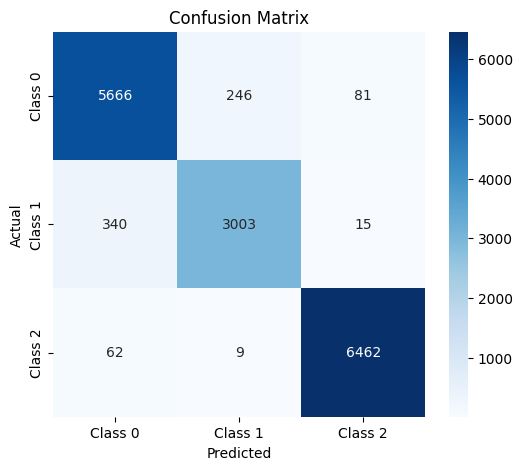


Precision: 0.9524369029068595
Recall: 0.9525938050868799
F1 Score: 0.9524563099674765
ROC-AUC: 0.9939831515980362

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.93      0.95      0.94      5993
     Class 1       0.92      0.89      0.91      3358
     Class 2       0.99      0.99      0.99      6533

    accuracy                           0.95     15884
   macro avg       0.95      0.94      0.94     15884
weighted avg       0.95      0.95      0.95     15884



In [17]:
#%%
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# --------------------------------------------------
# 1. GET PREDICTIONS
# --------------------------------------------------

# For TensorFlow / Keras
y_prob = PHASE1.predict(val_ds)

# Convert probabilities -> predicted class
y_pred = np.argmax(y_prob, axis=1)


# --------------------------------------------------
# 2. ACCURACY
# --------------------------------------------------

accuracy = accuracy_score(label_, y_pred)

print("Accuracy:", accuracy)


# --------------------------------------------------
# 3. CONFUSION MATRIX
# --------------------------------------------------

cm = confusion_matrix(label_, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1", "Class 2"],
    yticklabels=["Class 0", "Class 1", "Class 2"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# --------------------------------------------------
# 4. PRECISION
# --------------------------------------------------

precision = precision_score(
    label_,
    y_pred,
    average="weighted"
)

print("\nPrecision:", precision)


# --------------------------------------------------
# 5. RECALL
# --------------------------------------------------

recall = recall_score(
    label_,
    y_pred,
    average="weighted"
)

print("Recall:", recall)


# --------------------------------------------------
# 6. F1 SCORE
# --------------------------------------------------

f1 = f1_score(
    label_,
    y_pred,
    average="weighted"
)

print("F1 Score:", f1)


# --------------------------------------------------
# 7. ROC-AUC
# --------------------------------------------------

roc_auc = roc_auc_score(
    label_,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC:", roc_auc)


# --------------------------------------------------
# 8. COMPLETE CLASSIFICATION REPORT
# --------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        label_,
        y_pred,
        target_names=["Class 0", "Class 1", "Class 2"]
    )
)

>as we can see above we were able to achieve a validation accuracy of 95% which is far better then our 65% accuracy on a 3 block cnn network on the same dataset that we peeviously created

In [ ]:
PHASE1.save('EfficientNetB4_fd.keras')